In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: The file may be .xlsx or .csv or .tsv — adjust the name if needed
df = pd.read_excel("../data/HotelCustomersDataset.xlsx")   # try this first
# If it fails, try:
# df = pd.read_csv("../data/HotelCustomersDataset.csv")
# or
# df = pd.read_csv("../data/HotelCustomersDataset.tsv", sep="\t")

print("Data loaded successfully!")
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
df.head()

Data loaded successfully!
Shape: (83590, 31)

Column names:
['ID', 'Nationality', 'Age', 'DaysSinceCreation', 'NameHash', 'DocIDHash', 'AverageLeadTime', 'LodgingRevenue', 'OtherRevenue', 'BookingsCanceled', 'BookingsNoShowed', 'BookingsCheckedIn', 'PersonsNights', 'RoomNights', 'DaysSinceLastStay', 'DaysSinceFirstStay', 'DistributionChannel', 'MarketSegment', 'SRHighFloor', 'SRLowFloor', 'SRAccessibleRoom', 'SRMediumFloor', 'SRBathtub', 'SRShower', 'SRCrib', 'SRKingSizeBed', 'SRTwinBed', 'SRNearElevator', 'SRAwayFromElevator', 'SRNoAlcoholInMiniBar', 'SRQuietRoom']


,ID,Nationality,Age,DaysSinceCreation,NameHash,DocIDHash,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,0x8E0A7AF39B633D5EA25C3B7EF4DFC5464B36DB7AF375...,0x71568459B729F7A7ABBED6C781A84CA4274D571003AC...,45,371.0,105.3,1,...,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,0x21EDE41906B45079E75385B5AA33287CA09DE1AB86DE...,0x5FA1E0098A31497057C5A6B9FE9D49FD6DD47CCE7C26...,61,280.0,53.0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0x31C5E4B74E23231295FDB724AD578C02C4A723F4BA2B...,0xC7CF344F5B03295037595B1337AC905CA188F1B5B3A5...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,0xFF534C83C0EF23D1CE516BC80A65D0197003D27937D4...,0xBD3823A9B4EC35D6CAF4B27AE423A677C0200DB61E82...,93,240.0,60.0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0x9C1DEF02C9BE242842C1C1ABF2C5AA249A1EEB4763B4...,0xE175754CF77247B202DD0820F49407C762C14A603B3A...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nBasic satistics for key numerical columns:")
print(df[["Age", "AverageLeadTime", "LodgingRevenue", "OtherRevenue", "BookingsCheckedIn", "RoomNights", "DaysSinceLastStay"]].describe())

Missing values:
Age                  3779
ID                      0
Nationality             0
DaysSinceCreation       0
NameHash                0
DocIDHash               0
AverageLeadTime         0
LodgingRevenue          0
OtherRevenue            0
BookingsCanceled        0
dtype: int64

Basic satistics for key numerical columns:
                Age  AverageLeadTime  LodgingRevenue  OtherRevenue  \
count  79811.000000     83590.000000    83590.000000  83590.000000   
mean      45.398028        66.196028      298.802087     67.589132   
std       16.572368        87.758990      372.851892    114.327776   
min      -11.000000        -1.000000        0.000000      0.000000   
25%       34.000000         0.000000       59.000000      2.000000   
50%       46.000000        29.000000      234.000000     38.500000   
75%       57.000000       103.000000      402.000000     87.675000   
max      122.000000       588.000000    21781.000000   7730.250000   

       BookingsCheckedIn    RoomNigh

In [4]:
# Make a clean copy
df_clean = df.copy()

# Fix Age: replace negative ages and missing values with the median age 
median_age = df_clean["Age"].median()
df_clean["Age"] = df_clean["Age"].apply(lambda x: median_age if pd.isna(x) or x < 0 else x)

# Fix other negative values (set them to 0 or median where makes sense)
df_clean["AverageLeadTime"] = df_clean["AverageLeadTime"].apply(lambda x: 0 if x < 0 else x)
df_clean["DaysSinceLastStay"] = df_clean["DaysSinceLastStay"].apply(lambda x: 0 if x < 0 else x)
df_clean["DaysSinceFirstStay"] = df_clean["DaysSinceFirstStay"].apply(lambda x: 0 if x < 0 else x)

print("Cleaning done.")
print("Remaining missing values in Age:", df_clean["Age"].isnull().sum())
print("Shape after cleaning:", df_clean.shape)
print("\nAge statistics after cleaning:")
print(df_clean["Age"].describe())

Cleaning done.
Remaining missing values in Age: 0
Shape after cleaning: (83590, 31)

Age statistics after cleaning:
count    83590.000000
mean        45.436057
std         16.176452
min          0.000000
25%         34.000000
50%         46.000000
75%         56.000000
max        122.000000
Name: Age, dtype: float64


In [5]:
# Total Revenue per customer 
df_clean["TotalRevenue"] = df_clean["LodgingRevenue"] + df_clean["OtherRevenue"]

# Average revenue per night (if they stayed)
df_clean["RevenuePerNight"] = df_clean.apply(lambda row: row["TotalRevenue"] / row["RoomNights"] if row["RoomNights"] > 0 else 0, axis=1

)

# Is the customer a repeater? (simple flag)
df_clean["IsRepeater"] = (df_clean["BookingsCheckedIn"] > 1).astype(int)

print("New Features created:")
print(df_clean[["TotalRevenue", "RevenuePerNight", "IsRepeater"]].describe())

New Features created:
       TotalRevenue  RevenuePerNight    IsRepeater
count  83590.000000     83590.000000  83590.000000
mean     366.391219       120.681756      0.017406
std      443.800439       115.647641      0.130781
min        0.000000         0.000000      0.000000
25%       73.000000        62.165625      0.000000
50%      286.425000       114.240000      0.000000
75%      497.300000       155.000000      0.000000
max    23365.000000      2453.000000      1.000000


In [6]:
# Features we will use for segmentation
features = [
    "Age",
    "AverageLeadTime",
    "TotalRevenue",
    "RoomNights",
    "BookingsCheckedIn",
    "DaysSinceLastStay",
]

X = df_clean[features].copy()

print("Features selected for clustering:")
print(X.columns.tolist())
print("\nShape of X:", X.shape)
print("\nFirst 5 rows:")
print(X.head())

Features selected for clustering:
['Age', 'AverageLeadTime', 'TotalRevenue', 'RoomNights', 'BookingsCheckedIn', 'DaysSinceLastStay']

Shape of X: (83590, 6)

First 5 rows:
    Age  AverageLeadTime  TotalRevenue  RoomNights  BookingsCheckedIn  \
0  51.0               45         476.3           5                  3   
1  46.0               61         333.0           5                  1   
2  31.0                0           0.0           0                  0   
3  60.0               93         300.0           5                  1   
4  51.0                0           0.0           0                  0   

   DaysSinceLastStay  
0                151  
1               1100  
2                  0  
3               1100  
4                  0  


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Standardize the clustering features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test different numbers of clusters
k_values = range(2, 9)

inertias = []
silhouette_scores = []

# Use a sample for silhouette calculation to keep it fast
np.random.seed(42)
sample_size = min(10000, len(X_scaled))
sample_indices = np.random.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_indices]

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)

    score = silhouette_score(
        X_sample,
        labels[sample_indices]
    )

    silhouette_scores.append(score)

    print(
        f"k={k} | "
        f"Inertia={kmeans.inertia_:.2f} | "
        f"Silhouette Score={score:.4f}"
    )

k=2 | Inertia=364753.24 | Silhouette Score=0.3229
k=3 | Inertia=313557.75 | Silhouette Score=0.2941
k=4 | Inertia=275589.17 | Silhouette Score=0.3089
k=5 | Inertia=240173.47 | Silhouette Score=0.3078
k=6 | Inertia=213713.82 | Silhouette Score=0.2786
k=7 | Inertia=193333.31 | Silhouette Score=0.2868
k=8 | Inertia=178976.78 | Silhouette Score=0.2791


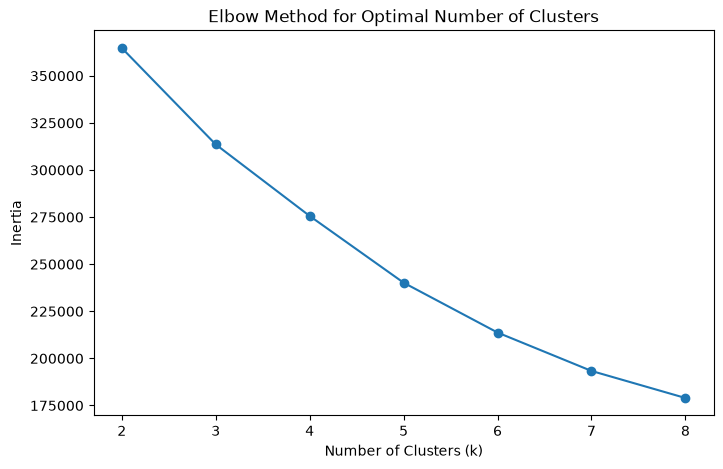

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.show()

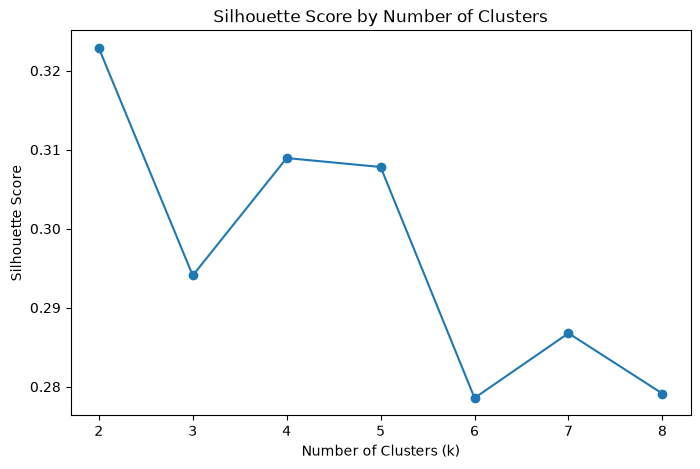

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.show()

In [10]:
# Final K-Means model using 4 clusters

final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_clean["Cluster"] = final_kmeans.fit_predict(X_scaled)

print("Final clustering completed.")
print("\nCustomers per cluster:")
print(df_clean["Cluster"].value_counts().sort_index())

Final clustering completed.

Customers per cluster:
Cluster
0     7239
1    41102
2    13919
3    21330
Name: count, dtype: int64


In [11]:
# Profile the final customer segments

profile_features = [
    "Age",
    "AverageLeadTime",
    "TotalRevenue",
    "RoomNights",
    "BookingsCheckedIn",
    "DaysSinceLastStay",
    "IsRepeater"
]

cluster_profile = (
    df_clean
    .groupby("Cluster")[profile_features]
    .mean()
    .round(1)
)

cluster_sizes = (
    df_clean["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_profile.insert(0, "Customers", cluster_sizes)

print("Customer Segment Profiles:")
display(cluster_profile)

Customer Segment Profiles:


,Customers,Age,AverageLeadTime,TotalRevenue,RoomNights,BookingsCheckedIn,DaysSinceLastStay,IsRepeater
Cluster,,,,,,,,
0,7239,44.6,88.2,1334.2,6.0,1.3,431.4,0.1
1,41102,45.0,45.0,361.4,2.6,1.0,573.7,0.0
2,13919,56.0,217.3,424.6,3.1,1.0,483.8,0.0
3,21330,39.6,1.0,9.6,0.1,0.1,5.2,0.0


In [12]:
segment_names = {
    0: "High-Value Loyal Guests",
    1: "Core Occasional Guests",
    2: "Advance-Planner Guests",
    3: "Low-Activity / New Guests"
}

df_clean["Segment"] = df_clean["Cluster"].map(segment_names)

print("Business segment names added.")
print()
print(df_clean["Segment"].value_counts())

Business segment names added.

Segment
Core Occasional Guests       41102
Low-Activity / New Guests    21330
Advance-Planner Guests       13919
High-Value Loyal Guests       7239
Name: count, dtype: int64


In [13]:
segment_summary = (
    df_clean
    .groupby(["Cluster", "Segment"])[profile_features]
    .mean()
    .round(1)
)

segment_counts = (
    df_clean
    .groupby(["Cluster", "Segment"])
    .size()
    .rename("Customers")
)

segment_summary.insert(0, "Customers", segment_counts)

segment_summary["Share (%)"] = (
    segment_summary["Customers"] / len(df_clean) * 100
).round(1)

display(segment_summary)

,,Customers,Age,AverageLeadTime,TotalRevenue,RoomNights,BookingsCheckedIn,DaysSinceLastStay,IsRepeater,Share (%)
Cluster,Segment,,,,,,,,,
0,High-Value Loyal Guests,7239,44.6,88.2,1334.2,6.0,1.3,431.4,0.1,8.7
1,Core Occasional Guests,41102,45.0,45.0,361.4,2.6,1.0,573.7,0.0,49.2
2,Advance-Planner Guests,13919,56.0,217.3,424.6,3.1,1.0,483.8,0.0,16.7
3,Low-Activity / New Guests,21330,39.6,1.0,9.6,0.1,0.1,5.2,0.0,25.5


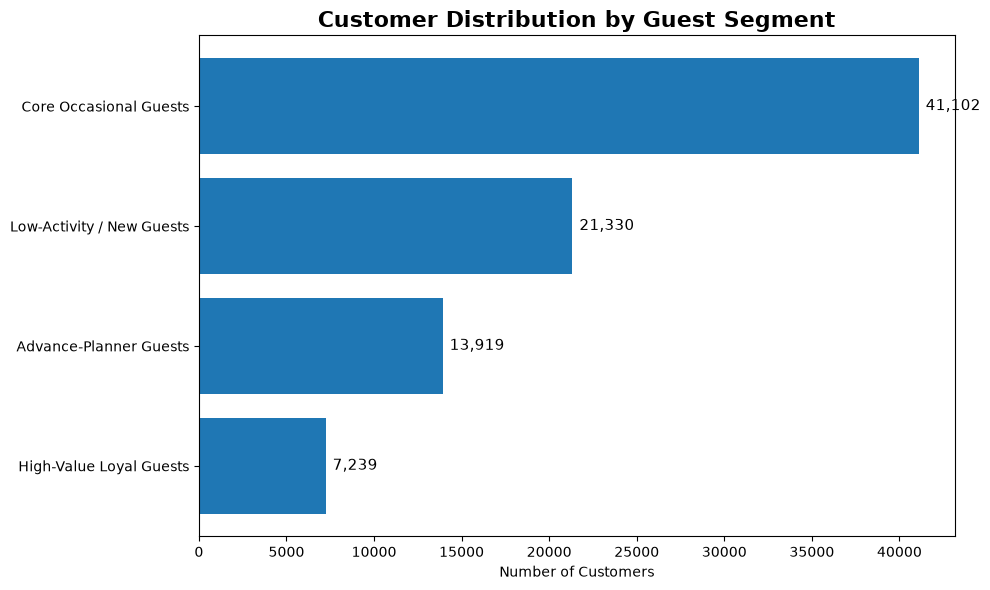

In [14]:
# Customer distribution by business segment

segment_distribution = (
    df_clean["Segment"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    segment_distribution.index,
    segment_distribution.values
)

plt.title(
    "Customer Distribution by Guest Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("")

# Add customer count labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 400,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

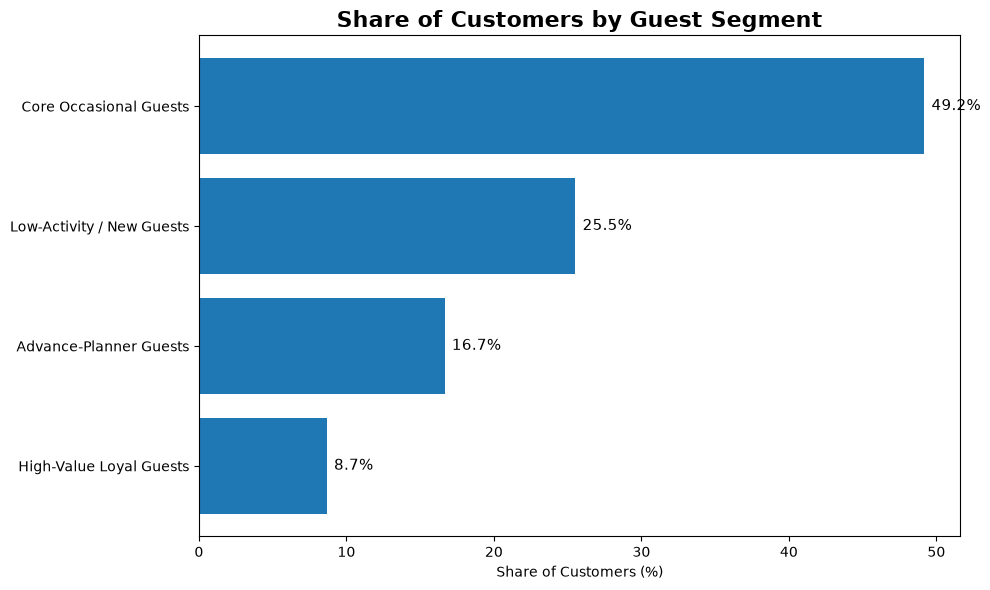

In [20]:
# Customer share by segment

segment_share = (
    df_clean["Segment"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    segment_share.index,
    segment_share.values
)

plt.title(
    "Share of Customers by Guest Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Share of Customers (%)")
plt.ylabel("")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=11
    )

plt.tight_layout()
plt.savefig(
    "../images/customer_share_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

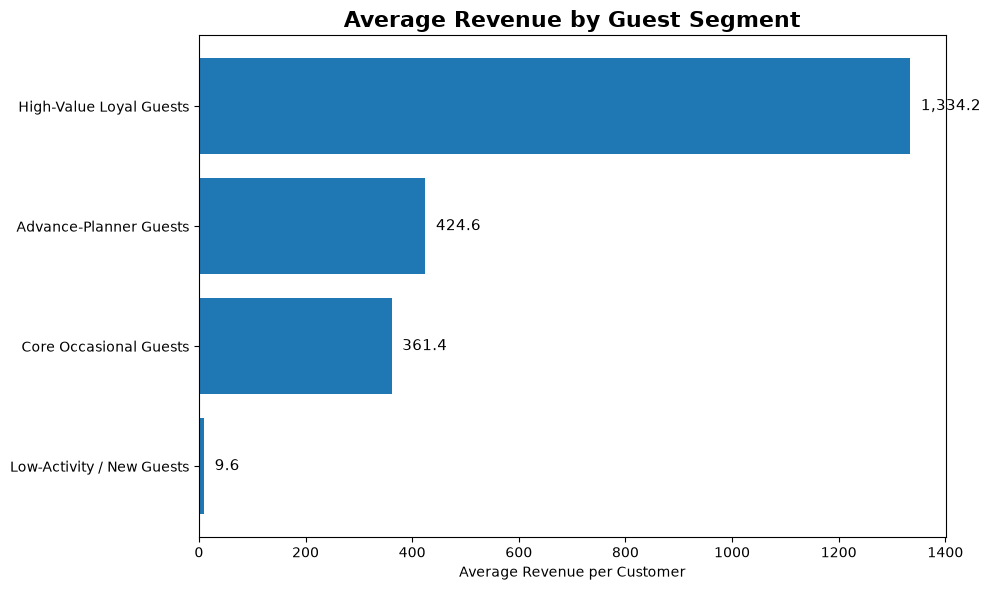

In [21]:
# Average revenue by guest segment

revenue_by_segment = (
    df_clean
    .groupby("Segment")["TotalRevenue"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    revenue_by_segment.index,
    revenue_by_segment.values
)

plt.title(
    "Average Revenue by Guest Segment",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Revenue per Customer")
plt.ylabel("")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.1f}",
        va="center",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "../images/average_revenue_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


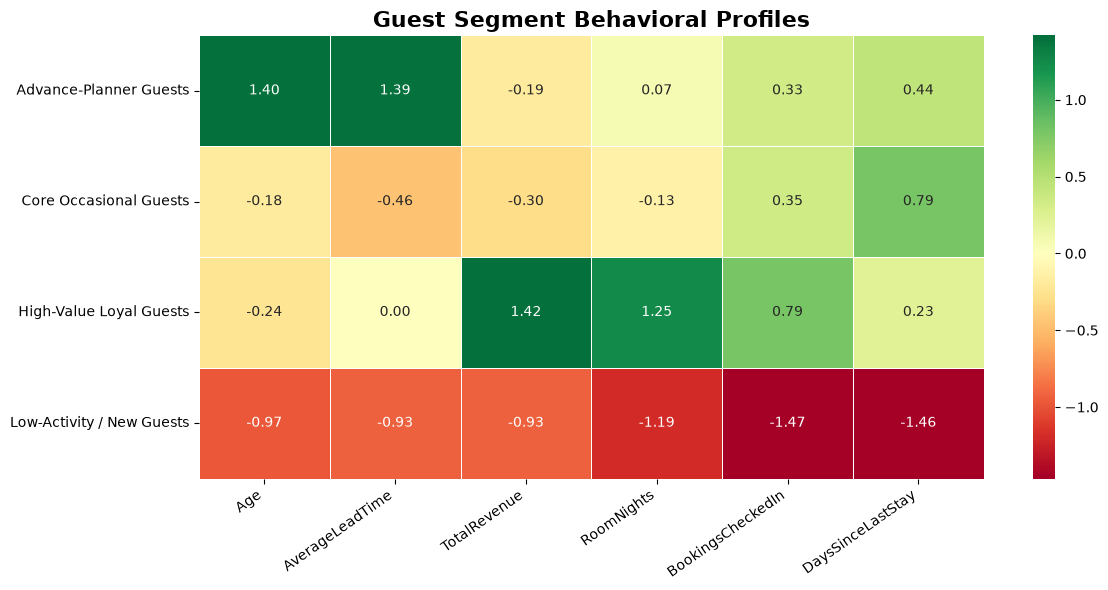

In [22]:
import seaborn as sns

# Features used to compare segment profiles
heatmap_features = [
    "Age",
    "AverageLeadTime",
    "TotalRevenue",
    "RoomNights",
    "BookingsCheckedIn",
    "DaysSinceLastStay"
]

# Calculate average profile for each segment
profile_matrix = (
    df_clean
    .groupby("Segment")[heatmap_features]
    .mean()
)

# Standardize each feature so different measurement scales can be compared
profile_normalized = (
    profile_matrix - profile_matrix.mean()
) / profile_matrix.std()

plt.figure(figsize=(12, 6))

sns.heatmap(
    profile_normalized,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)

plt.title(
    "Guest Segment Behavioral Profiles",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("")

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../images/segment_behavioral_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
import pandas as pd

business_recommendations = pd.DataFrame({
    "Segment": [
        "High-Value Loyal Guests",
        "Core Occasional Guests",
        "Advance-Planner Guests",
        "Low-Activity / New Guests"
    ],

    "Key Characteristics": [
        "Highest average revenue, longest stays and strongest repeat/check-in behavior",
        "Largest customer segment with moderate revenue and stay activity",
        "Older guests with very long booking lead times and moderate revenue",
        "Very low historical revenue, room nights and check-in activity"
    ],

    "Business Priority": [
        "Retention and lifetime value",
        "Increase loyalty and repeat visits",
        "Capture bookings early and protect future demand",
        "Activation and conversion"
    ],

    "Recommended Action": [
        "Offer loyalty benefits, VIP recognition, personalized upgrades and direct-booking incentives",
        "Use targeted return offers, loyalty enrollment and personalized reactivation campaigns",
        "Launch early-booking packages, advance-purchase offers and long-horizon seasonal campaigns",
        "Use onboarding offers, first-stay incentives and targeted campaigns designed to convert low-activity guests"
    ]
})

display(business_recommendations)

,Segment,Key Characteristics,Business Priority,Recommended Action
0,High-Value Loyal Guests,"Highest average revenue, longest stays and str...",Retention and lifetime value,"Offer loyalty benefits, VIP recognition, perso..."
1,Core Occasional Guests,Largest customer segment with moderate revenue...,Increase loyalty and repeat visits,"Use targeted return offers, loyalty enrollment..."
2,Advance-Planner Guests,Older guests with very long booking lead times...,Capture bookings early and protect future demand,"Launch early-booking packages, advance-purchas..."
3,Low-Activity / New Guests,"Very low historical revenue, room nights and c...",Activation and conversion,"Use onboarding offers, first-stay incentives a..."


In [19]:
from pathlib import Path

# Project folders
project_root = Path("..")
outputs_dir = project_root / "outputs"
images_dir = project_root / "images"

outputs_dir.mkdir(exist_ok=True)
images_dir.mkdir(exist_ok=True)

# Export segmented customer dataset
df_clean.to_csv(
    outputs_dir / "customer_segments.csv",
    index=False
)

# Export segment summary
segment_summary.to_csv(
    outputs_dir / "segment_summary.csv"
)

# Export business recommendations
business_recommendations.to_csv(
    outputs_dir / "business_recommendations.csv",
    index=False
)

print("Files exported successfully:")
print("- outputs/customer_segments.csv")
print("- outputs/segment_summary.csv")
print("- outputs/business_recommendations.csv")

Files exported successfully:
- outputs/customer_segments.csv
- outputs/segment_summary.csv
- outputs/business_recommendations.csv


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run K-Means with 4 clusters (a good starting number for hotels)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)

print("Clustering completed!")
print("\nNumber of customers in each cluster:")
print(df_clean["Cluster"].value_counts().sort_index())

Python(20916) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Clustering completed!

Number of customers in each cluster:
Cluster
0    20008
1    40670
2    21457
3     1455
Name: count, dtype: int64


In [15]:
# Profile the clusters
cluster_profile = df_clean.groupby("Cluster")[features + ["TotalRevenue"]].mean().round(1)

print("Average values per Cluster:")
print(cluster_profile)

print("\n\nCluster size again:")
print(df_clean["Cluster"].value_counts().sort_index())

Average values per Cluster:
          Age  AverageLeadTime  TotalRevenue  RoomNights  BookingsCheckedIn  \
Cluster                                                                       
0        53.0            180.7         699.6         4.0                1.0   
1        44.6             44.7         369.4         2.6                1.0   
2        39.6              1.2          10.6         0.1                0.1   
3        50.1             52.0         948.2         5.8                2.9   

         DaysSinceLastStay  IsRepeater  TotalRevenue  
Cluster                                               
0                    458.3         0.0         699.6  
1                    583.6         0.0         369.4  
2                      5.6         0.0          10.6  
3                    358.9         1.0         948.2  


Cluster size again:
Cluster
0    20008
1    40670
2    21457
3     1455
Name: count, dtype: int64


In [16]:
print("="*60)
print("PROJECT 3 SUMMARY - Guest Segmentation for Targeted Marketing")
print("="*60)
print(f"Total customers analyzed: {len(df_clean)}")
print("\nSegment Overview:")
print(df_clean["Cluster"].value_counts().sort_index())
print("\nAverage Total Revenue by Segment:")
print(df_clean.groupby("Cluster")["TotalRevenue"].mean().round(1))

PROJECT 3 SUMMARY - Guest Segmentation for Targeted Marketing
Total customers analyzed: 83590

Segment Overview:
Cluster
0    20008
1    40670
2    21457
3     1455
Name: count, dtype: int64

Average Total Revenue by Segment:
Cluster
0    699.6
1    369.4
2     10.6
3    948.2
Name: TotalRevenue, dtype: float64
